# Lab Day 19 — Building a GraphRAG System

**Goal:** build a full **GraphRAG** pipeline from a raw text corpus and compare it
against a plain **Flat RAG** baseline.

This notebook walks through the lab end-to-end:

1. **Entity & Relation Extraction** — turn unstructured text into `(subject, relation, object)` triples with an LLM or **[LangExtract](https://github.com/google/langextract)** (few-shot, source-grounded extraction).
2. **Graph Construction** — deduplicate entities and build a knowledge graph (**NetworkX**, optionally mirrored to **Neo4j**).
3. **Indexing** — embed chunks into a vector index for retrieval.
4. **GraphRAG Querying** — link a question to graph entities, traverse a **multi-hop** subgraph, and answer from graph facts + supporting text.
5. **Flat RAG vs GraphRAG** — run the same questions through both and compare.

> **Runs offline by default** using **Ollama** + **NetworkX** (no API key, no database).
> Switch to **OpenAI** and/or **Neo4j** by changing the single `CONFIG` cell below.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Part 0 — Setup & Configuration

**Before running:**

- *Offline path (default):* install [Ollama](https://ollama.com), then in a terminal:
  ```
  ollama serve
  ollama pull llama3.1
  ollama pull nomic-embed-text
  ```
- *OpenAI path:* set `LLM_PROVIDER = "openai"` in CONFIG and export `OPENAI_API_KEY`.
- *LangExtract path (recommended):* set `EXTRACTION_BACKEND = "langextract"` in CONFIG — works with Ollama (offline) or OpenAI; uses few-shot examples for more consistent triples.
- *Neo4j (optional):* set `GRAPH_BACKEND = "neo4j"` and fill the Neo4j credentials.

In [2]:
%pip install -q networkx numpy pandas matplotlib requests tqdm google-generativeai neo4j langextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.1/142.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.1 MB/s eta 0:00:00


In [3]:
!sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > /dev/null 2>&1 &
import time
time.sleep(3)
!ollama pull llama3.1
!ollama pull nomic-embed-text

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (2,614 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently

In [4]:
import os, re, json, glob, difflib, collections
import numpy as np
import pandas as pd
import requests
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [6]:
# ====================== CONFIG ======================
LLM_PROVIDER       = "ollama"        # "ollama" | "openai" | "gemini"
GRAPH_BACKEND      = "networkx"      # "networkx" | "neo4j"
EXTRACTION_BACKEND = "prompt"   # "langextract" | "prompt"

# --- Gemini (used when LLM_PROVIDER == "gemini") ---
# Hãy đảm bảo bạn đã đặt GOOGLE_API_KEY trong phần Secrets của Colab
GEMINI_MODEL       = "gemini-2.0-flash-exp"
GEMINI_EMBED_MODEL = "models/text-embedding-004"

# --- OpenAI (used when LLM_PROVIDER == "openai") ---
OPENAI_MODEL       = "gpt-4o-mini"
OPENAI_EMBED_MODEL = "text-embedding-3-small"

# --- Ollama ---
OLLAMA_HOST        = "http://localhost:11434"
OLLAMA_MODEL       = "llama3.1"
OLLAMA_EMBED_MODEL = "nomic-embed-text"

# --- Data / runtime ---
DATASET_DIR   = "dataset"
MAX_DOCS      = 12
CHUNK_SIZE    = 1200
CHUNK_OVERLAP = 150

print(f"LLM_PROVIDER={LLM_PROVIDER} | EXTRACTION_BACKEND={EXTRACTION_BACKEND} | GRAPH_BACKEND={GRAPH_BACKEND}")

LLM_PROVIDER=ollama | EXTRACTION_BACKEND=prompt | GRAPH_BACKEND=networkx


In [5]:
# ---- Provider-agnostic LLM + embedding wrappers ----
import google.generativeai as genai
from google.colab import userdata

def llm_complete(prompt, system=None, temperature=0.0, max_tokens=1200):
    if LLM_PROVIDER == "gemini":
        genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))
        model = genai.GenerativeModel(
            model_name=GEMINI_MODEL,
            system_instruction=system
        )
        resp = model.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(
                temperature=temperature,
                max_output_tokens=max_tokens
            )
        )
        return resp.text

    elif LLM_PROVIDER == "openai":
        from openai import OpenAI
        client = OpenAI()
        messages = []
        if system: messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": prompt})
        resp = client.chat.completions.create(
            model=OPENAI_MODEL, messages=messages,
            temperature=temperature, max_tokens=max_tokens)
        return resp.choices[0].message.content

    elif LLM_PROVIDER == "ollama":
        payload = {"model": OLLAMA_MODEL, "prompt": prompt, "stream": False,
                   "options": {"temperature": temperature, "num_predict": max_tokens}}
        if system: payload["system"] = system
        r = requests.post(OLLAMA_HOST + "/api/generate", json=payload, timeout=600)
        r.raise_for_status()
        return r.json()["response"]
    raise ValueError("Unknown LLM_PROVIDER: " + LLM_PROVIDER)

def embed(texts):
    if isinstance(texts, str):
        texts = [texts]

    if LLM_PROVIDER == "gemini":
        genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))
        result = genai.embed_content(model=GEMINI_EMBED_MODEL, content=texts, task_type="retrieval_document")
        return [np.array(e, dtype=float) for e in result['embedding']]

    if LLM_PROVIDER == "openai":
        from openai import OpenAI
        client = OpenAI()
        resp = client.embeddings.create(model=OPENAI_EMBED_MODEL, input=texts)
        return [np.array(d.embedding, dtype=float) for d in resp.data]

    out = []
    for t in texts:
        r = requests.post(OLLAMA_HOST + "/api/embeddings",
                          json={"model": OLLAMA_EMBED_MODEL, "prompt": t}, timeout=600)
        r.raise_for_status()
        out.append(np.array(r.json()["embedding"], dtype=float))
    return out

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [7]:
# Smoke test — verifies the chosen provider responds (safe to re-run).
try:
    print("LLM says:", llm_complete("Reply with exactly: OK", max_tokens=10).strip()[:50])
    print("Embedding dim:", len(embed("hello world")[0]))
except Exception as e:
    print("Provider not reachable yet:", e)
    print("Ollama:  run `ollama serve` and pull `llama3.1` + `nomic-embed-text`.")
    print("OpenAI:  set LLM_PROVIDER='openai' and export OPENAI_API_KEY.")

LLM says: OK
Embedding dim: 768


## Part 1 — Concepts (the lab's research questions)

**1. Entity Extraction — how does the LLM tell an *entity* from an *attribute*?**
We extract structured triples `(subject, relation, object)` with entity *types*.
By default we use **[LangExtract](https://github.com/google/langextract)** — few-shot examples
teach the schema, and each extraction can be traced back to its source span. The `prompt`
backend is a simpler single-shot JSON alternative. Entities become *nodes*; relationships become *edges*.

**2. Graph Construction — why does deduplication matter?**
The same real-world entity appears under many surface forms ("Tesla", "Tesla Inc.", "tesla").
If we don't merge them, the graph fragments: facts about one entity scatter across several nodes,
breaking traversal. We normalize names and fuzzy-merge near-duplicates into a single canonical node.

**3. Query Answering — graph traversal vs. plain vector search?**
*Flat RAG* embeds the query and returns the top-k most *similar* chunks — great for "what does the text say
about X", but blind to relationships that aren't co-located in one passage.
*GraphRAG* links the query to entities and **traverses** the graph (multi-hop) to assemble connected facts —
so it can answer "how is A connected to C *through* B" even when no single chunk states it.

## Part 2 — Load & Chunk the Corpus

We read the `*.txt` files from `DATASET_DIR` and split each into overlapping character chunks.

In [8]:

!unzip -q -o /content/dataset.zip -d /content/
DATASET_DIR = "/content/dataset"

def load_documents(directory, max_docs=None):
    paths = sorted(glob.glob(os.path.join(directory, "*.txt")))
    if max_docs:
        paths = paths[:max_docs]
    docs = []
    for p in paths:
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            docs.append({"doc_id": os.path.basename(p), "text": f.read()})
    return docs

def chunk_text(text, size, overlap):
    text = text.strip()
    chunks, start = [], 0
    while start < len(text):
        end = start + size
        chunks.append(text[start:end])
        if end >= len(text):
            break
        start = max(0, end - overlap)
    return chunks


documents = load_documents(DATASET_DIR, MAX_DOCS)
chunks = []
for d in documents:
    for j, ctext in enumerate(chunk_text(d["text"], CHUNK_SIZE, CHUNK_OVERLAP)):
        chunks.append({"chunk_id": f"{d['doc_id']}::ch{j}",
                       "doc_id": d["doc_id"], "text": ctext})

print(f"Loaded {len(documents)} docs -> {len(chunks)} chunks")
print("\nExample chunk:\n", chunks[0]["text"][:300])

Loaded 12 docs -> 211 chunks

Example chunk:
 Query: US electric vehicle sector sentiment analysis
Title: Evaluating electric vehicle market growth across U.S. cities ...
Link: https://theicct.org/publication/evaluating-electric-vehicle-market-growth-across-u-s-cities/
Snippet: Sep 14, 2021 ... This study, an update of our previous analysis of 


## Part 3 — Entity & Relation Extraction

Two backends (set `EXTRACTION_BACKEND` in CONFIG):

| Backend | How it works | Best for |
|---------|--------------|----------|
| **`langextract`** (default) | Google's [LangExtract](https://github.com/google/langextract) library — few-shot examples, schema-guided output, source grounding | More consistent triples; same Ollama/OpenAI provider as the rest of the lab |
| **`prompt`** | Single-shot JSON prompt to the LLM | Minimal dependencies; quick baseline |

Both produce the same `(subject, relation, object)` triple list consumed by graph construction below.

In [9]:
import textwrap
import langextract as lx

# ... (parse_json_triples and extract_triples_prompt stay the same) ...
def parse_json_triples(raw):
    if not raw: return []
    text = raw.strip()
    text = re.sub(r"^```[a-zA-Z]*", "", text).strip().strip("`").strip()
    try:
        data = json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if not m: return []
        try: data = json.loads(m.group(0))
        except Exception: return []
    return data.get("triples", []) if isinstance(data, dict) else []

EXTRACT_SYSTEM = "You are an information-extraction engine that builds knowledge graphs from text."

def extract_triples_prompt(text):
    prompt = (
        "Extract the key ENTITIES and RELATIONSHIPS from the text below.\n"
        "Return ONLY valid JSON in this exact shape (no prose, no markdown):\n"
        '{"triples": [{"subject": "", "subject_type": "", "relation": "", "object": "", "object_type": ""}]}\n\n'
        "Guidelines:\n"
        "- subject/object must be specific named entities (company, sector, technology, product, place, person, metric).\n"
        "- relation is a short snake_case verb phrase: operates_in, invests_in, competes_with, located_in, produces, reported.\n"
        "- Use canonical, concise entity names. Skip vague pronouns.\n"
        "- Return at most 15 of the most important triples.\n\n"
        "Text:\n<<<\n" + text[:3500] + "\n>>>"
    )
    raw = llm_complete(prompt, system=EXTRACT_SYSTEM, max_tokens=1200)
    return parse_json_triples(raw)

# Updated model kwargs for LangExtract to support Gemini
def _langextract_model_kwargs():
    if LLM_PROVIDER == "ollama":
        return {"model_id": OLLAMA_MODEL, "model_url": OLLAMA_HOST}
    if LLM_PROVIDER == "openai":
        return {"model_id": OPENAI_MODEL}
    if LLM_PROVIDER == "gemini":
        return {"model_id": GEMINI_MODEL, "api_key": userdata.get('GOOGLE_API_KEY')}
    raise ValueError("Unknown LLM_PROVIDER: " + LLM_PROVIDER)

# ... (Rest of extraction functions remain the same) ...
def lx_extractions_to_triples(result):
    triples = []
    for ext in (result.extractions or []):
        if ext.extraction_class != "relationship": continue
        attrs = ext.attributes or {}
        s, o, r = attrs.get("subject"), attrs.get("object"), attrs.get("relation")
        if not (s and o and r): continue
        triples.append({
            "subject": str(s).strip(), "subject_type": str(attrs.get("subject_type", "")).strip(),
            "relation": str(r).strip(), "object": str(o).strip(),
            "object_type": str(attrs.get("object_type", "")).strip(),
        })
    return triples

def extract_triples_langextract(text):
    result = lx.extract(
        text_or_documents=text[:3500],
        prompt_description=LX_PROMPT,
        examples=LX_EXAMPLES,
        max_char_buffer=min(CHUNK_SIZE, 1200),
        **_langextract_model_kwargs(),
    )
    return lx_extractions_to_triples(result)

def extract_triples(text):
    if EXTRACTION_BACKEND == "langextract": return extract_triples_langextract(text)
    if EXTRACTION_BACKEND == "prompt": return extract_triples_prompt(text)
    raise ValueError("Unknown EXTRACTION_BACKEND: " + EXTRACTION_BACKEND)

In [10]:
# Run extraction across all chunks (limited by MAX_DOCS). This is the slow step.
all_triples = []   # each: chunk_id, doc_id, subject, subject_type, relation, object, object_type

for ch in tqdm(chunks, desc=f"Extracting ({EXTRACTION_BACKEND})"):
    try:
        triples = extract_triples(ch["text"])
    except Exception:
        triples = []
    for t in triples:
        if not (t.get("subject") and t.get("object") and t.get("relation")):
            continue
        all_triples.append({
            "chunk_id": ch["chunk_id"], "doc_id": ch["doc_id"],
            "subject": str(t["subject"]).strip(),
            "subject_type": str(t.get("subject_type", "")).strip(),
            "relation": str(t["relation"]).strip(),
            "object": str(t["object"]).strip(),
            "object_type": str(t.get("object_type", "")).strip(),
        })

print(f"Extracted {len(all_triples)} raw triples from {len(chunks)} chunks")

Extracting (prompt):   0%|          | 0/211 [00:00<?, ?it/s]

Extracted 1476 raw triples from 211 chunks


In [11]:
pd.DataFrame(all_triples).head(15)

,chunk_id,doc_id,subject,subject_type,relation,object,object_type
0,doc_1.txt::ch0,doc_1.txt,United States,place,operates_in,electric vehicle market,sector
1,doc_1.txt::ch0,doc_1.txt,Anh Bui,person,authored,study,product
2,doc_1.txt::ch0,doc_1.txt,Peter Slowik,person,authored,study,product
3,doc_1.txt::ch0,doc_1.txt,Nic Lutsey,person,authored,study,product
4,doc_1.txt::ch0,doc_1.txt,electric vehicle market,sector,grew_from,few thousand vehicles,metric
5,doc_1.txt::ch0,doc_1.txt,electric vehicle market,sector,sold_in,United States,place
6,doc_1.txt::ch0,doc_1.txt,2020,metric,reported,2.4%,metric
7,doc_1.txt::ch0,doc_1.txt,2019,metric,reported,2%,metric
8,doc_1.txt::ch0,doc_1.txt,states and cities,place,have_policy_supports,electric vehicle market success,sector
9,doc_1.txt::ch1,doc_1.txt,Electric vehicle,Technology,required_by_regulations,Market growth,


### (Optional) LangExtract source-grounding visualization

When `EXTRACTION_BACKEND == "langextract"`, re-run extraction on one chunk and generate
an interactive HTML map of extractions back to source text spans.

In [ ]:
if EXTRACTION_BACKEND == "langextract":
    demo_text = chunks[0]["text"][:2500]
    lx_result = lx.extract(
        text_or_documents=demo_text,
        prompt_description=LX_PROMPT,
        examples=LX_EXAMPLES,
        max_char_buffer=min(CHUNK_SIZE, 1200),
        **_langextract_model_kwargs(),
    )
    lx.io.save_annotated_documents([lx_result], output_name="lx_demo.jsonl", output_dir=".")
    html = lx.visualize("lx_demo.jsonl")
    html_path = "lx_extraction_viz.html"
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html.data if hasattr(html, "data") else html)
    print(f"Saved interactive visualization -> {html_path}")
    print(f"Grounded extractions: {sum(1 for e in lx_result.extractions if e.char_interval)} / {len(lx_result.extractions)}")
else:
    print("Set EXTRACTION_BACKEND='langextract' to generate the HTML visualization.")

## Part 4 — Graph Construction (with Deduplication)

We normalize entity names and fuzzy-merge near-duplicates into canonical nodes,
then build a directed multigraph in **NetworkX**. Each edge remembers which chunk it came from
(provenance), so GraphRAG can pull the supporting text later.

In [12]:
def normalize(name):
    n = re.sub(r"\s+", " ", str(name)).strip()
    return n.strip(' .,:;"\'')

# Build a canonical alias map by fuzzy-merging surface forms.
raw_entities = sorted({normalize(t[k]) for t in all_triples for k in ("subject", "object")} - {""})

canonical, canon_list = {}, []
for e in raw_entities:
    match = difflib.get_close_matches(e.lower(), [c.lower() for c in canon_list], n=1, cutoff=0.92)
    if match:
        canonical[e] = next(c for c in canon_list if c.lower() == match[0])
    else:
        canon_list.append(e)
        canonical[e] = e

def canon(name):
    return canonical.get(normalize(name), normalize(name))

print(f"{len(raw_entities)} surface entities -> {len(canon_list)} canonical entities after dedup")

1382 surface entities -> 1320 canonical entities after dedup


In [13]:
G = nx.MultiDiGraph()
entity_chunks = {}   # canonical entity -> set of chunk_ids (provenance)
entity_type = {}

for t in all_triples:
    s, o = canon(t["subject"]), canon(t["object"])
    if not s or not o:
        continue
    if t["subject_type"]:
        entity_type.setdefault(s, t["subject_type"])
    if t["object_type"]:
        entity_type.setdefault(o, t["object_type"])
    G.add_node(s, type=entity_type.get(s, ""))
    G.add_node(o, type=entity_type.get(o, ""))
    G.add_edge(s, o, relation=t["relation"], chunk_id=t["chunk_id"], doc_id=t["doc_id"])
    entity_chunks.setdefault(s, set()).add(t["chunk_id"])
    entity_chunks.setdefault(o, set()).add(t["chunk_id"])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 1320 nodes, 1476 edges


In [14]:
print("Top entities by degree:")
for n, d in sorted(G.degree, key=lambda x: x[1], reverse=True)[:15]:
    print(f"  {d:3d}  {n}  ({G.nodes[n].get('type','')})")

Top entities by degree:
  173  Polestar  (company)
   80  REE  (company)
   72  NVIDIA  (company)
   68  VinFast  (company)
   48  Electric Vehicles  (Technology)
   48  China  (place)
   44  ZEEKR  (company)
   43  Tesla  (company)
   35  ZEEKR INC  (company)
   28  Polestar Automotive Holding UK PLC  (company)
   26  United States  (place)
   26  Mercedes-Benz  (company)
   24  Company  (organization)
   22  BYD  (company)
   21  BloombergNEF  (organization)


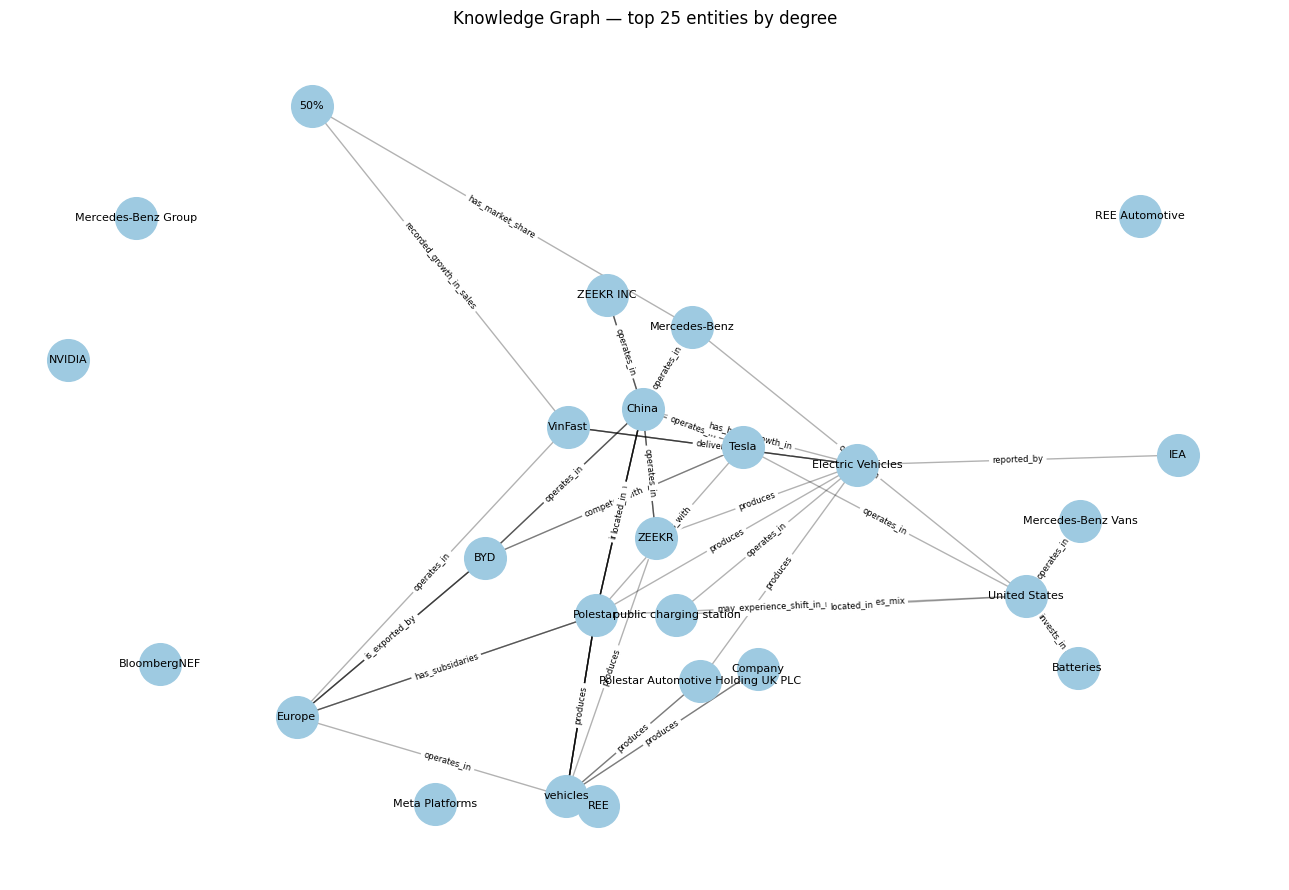

In [15]:
# Visualize the most-connected slice of the graph
top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:25]]
H = G.subgraph(top_nodes)

plt.figure(figsize=(13, 9))
pos = nx.spring_layout(H, k=0.6, seed=42)
nx.draw_networkx_nodes(H, pos, node_size=900, node_color="#9ecae1")
nx.draw_networkx_labels(H, pos, font_size=8)
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=True)
nx.draw_networkx_edge_labels(
    H, pos, font_size=6,
    edge_labels={(u, v): d["relation"] for u, v, d in H.edges(data=True)})
plt.title("Knowledge Graph — top 25 entities by degree")
plt.axis("off"); plt.tight_layout(); plt.show()

### (Optional) Mirror the graph into Neo4j

Runs only when `GRAPH_BACKEND == "neo4j"` and credentials are set — otherwise it is skipped,
so the notebook still runs fully offline.

In [ ]:
if GRAPH_BACKEND == "neo4j":
    from neo4j import GraphDatabase
    driver = GraphDatabase.driver(NEO4J_URL, auth=(NEO4J_USER, NEO4J_PASSWORD))
    with driver.session() as session:
        session.run("MATCH (n) DETACH DELETE n")
        for n, data in G.nodes(data=True):
            session.run("MERGE (e:Entity {name:$name}) SET e.type=$type",
                        name=n, type=data.get("type", ""))
        for u, v, data in G.edges(data=True):
            session.run(
                "MATCH (a:Entity {name:$u}), (b:Entity {name:$v}) "
                "MERGE (a)-[r:REL {type:$rel}]->(b) SET r.doc_id=$doc",
                u=u, v=v, rel=data.get("relation", ""), doc=data.get("doc_id", ""))
    driver.close()
    print("Pushed graph to Neo4j at", NEO4J_URL)
else:
    print("GRAPH_BACKEND != 'neo4j' -> skipping. Set GRAPH_BACKEND='neo4j' + creds in CONFIG to enable.")

**Multi-hop traversal in Cypher** (run in the Neo4j Browser once the graph is loaded):

```cypher
// 2-hop neighbourhood around an entity
MATCH path = (a:Entity {name: "Tesla"})-[*1..2]-(b:Entity)
RETURN path LIMIT 50;
```

## Part 5 — Vector Index (for the Flat RAG baseline)

A minimal cosine-similarity index over the chunk embeddings — this is what plain RAG retrieves from.

In [16]:
class VectorIndex:
    def __init__(self):
        self.ids, self.meta, self.matrix = [], {}, None

    def build(self, items):
        vecs = []
        for it in tqdm(items, desc="Embedding"):
            vecs.append(embed(it["text"])[0])
            self.ids.append(it["chunk_id"])
            self.meta[it["chunk_id"]] = it
        m = np.vstack(vecs)
        self.matrix = m / (np.linalg.norm(m, axis=1, keepdims=True) + 1e-9)

    def search(self, query, k=4):
        q = embed(query)[0]
        q = q / (np.linalg.norm(q) + 1e-9)
        sims = self.matrix @ q
        order = np.argsort(-sims)[:k]
        return [(self.ids[i], float(sims[i]), self.meta[self.ids[i]]) for i in order]

vindex = VectorIndex()
vindex.build(chunks)
print("Vector index:", len(vindex.ids), "chunks, dim =", vindex.matrix.shape[1])

Embedding:   0%|          | 0/211 [00:00<?, ?it/s]

Vector index: 211 chunks, dim = 768


## Part 6 — GraphRAG Querying (multi-hop)

The GraphRAG retrieval pipeline:

1. **Entity linking** — find graph nodes mentioned in the question.
2. **Multi-hop traversal** — expand a k-hop subgraph around those seeds.
3. **Verbalize** the subgraph edges into facts + pull the **provenance chunks**.
4. **Answer** from graph facts *and* supporting text.

In [17]:
def link_entities(query, max_seeds=5):
    ql = query.lower()
    seeds = [n for n in G.nodes if n.lower() in ql]
    if not seeds:                      # fuzzy fallback on query tokens
        names = list(G.nodes)
        for token in re.findall(r"[A-Za-z][A-Za-z0-9&.\- ]{2,}", query):
            m = difflib.get_close_matches(token.strip().lower(),
                                          [x.lower() for x in names], n=1, cutoff=0.8)
            if m:
                seeds += [x for x in names if x.lower() == m[0] and x not in seeds]
    return sorted(set(seeds), key=lambda n: G.degree(n), reverse=True)[:max_seeds]

def k_hop_subgraph(seeds, hops=2, max_nodes=40):
    nodes, frontier = set(seeds), set(seeds)
    for _ in range(hops):
        nxt = set()
        for n in frontier:
            nxt.update(G.successors(n)); nxt.update(G.predecessors(n))
        nodes.update(nxt); frontier = nxt
        if len(nodes) >= max_nodes:
            break
    return G.subgraph(list(nodes)[:max_nodes])

def verbalize(sg):
    lines = {f"({u}) -[{d.get('relation','related_to')}]-> ({v})"
             for u, v, d in sg.edges(data=True)}
    return "\n".join(sorted(lines))

def gather_chunks(sg, limit=6):
    cids, texts = [], []
    for n in sg.nodes:
        for cid in entity_chunks.get(n, []):
            if cid not in cids:
                cids.append(cid)
    by_id = {c["chunk_id"]: c for c in chunks}
    for cid in cids[:limit]:
        if cid in by_id:
            texts.append(f"[{cid}] " + by_id[cid]["text"][:600])
    return texts

def graphrag_answer(query, hops=2):
    seeds = link_entities(query)
    sg = k_hop_subgraph(seeds, hops=hops)
    facts = verbalize(sg)
    evidence = "\n\n".join(gather_chunks(sg))
    prompt = (
        "Answer the question using the KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT below. "
        "Reason across multiple connected facts (multi-hop) when needed. "
        "If the context is insufficient, say so.\n\n"
        "QUESTION: " + query + "\n\n"
        "KNOWLEDGE-GRAPH FACTS:\n" + (facts or "(none found)") + "\n\n"
        "SUPPORTING TEXT:\n" + (evidence or "(none)") + "\n\n"
        "ANSWER:"
    )
    return {"answer": llm_complete(prompt, max_tokens=500), "seeds": seeds,
            "n_facts": len(facts.splitlines()) if facts else 0}

In [18]:
q = "How does the electric vehicle sector connect to charging infrastructure and government policy?"
res = graphrag_answer(q, hops=2)
print("Seed entities:", res["seeds"])
print("Graph facts used:", res["n_facts"])
print("\nGraphRAG answer:\n", res["answer"])

Seed entities: ['SEC', 'Charging Infrastructure']
Graph facts used: 7

GraphRAG answer:
 Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can answer the question as follows:

The electric vehicle sector connects to charging infrastructure and government policy in several ways:

1. **Charging Infrastructure**: The transportation sector is where charging infrastructure is located (KNOWLEDGE-GRAPH FACT: "Charging Infrastructure" -[located_in]-> "transportation sector"). This implies that charging infrastructure is a crucial component of the electric vehicle ecosystem.
2. **Government Policy**: The use of electric vehicles supports the U.S. economy and helps diversify the U.S. transportation fleet (SUPPORTING TEXT: [doc_17.txt::ch9]). This suggests that government policies promoting the adoption of electric vehicles can have positive economic and environmental impacts.
3. **Energy Security**: Electric vehicles avoid oil consumption, which strengthens national energy secur

## Part 7 — Flat RAG Baseline

Plain retrieval: embed the query, grab the top-k most similar chunks, answer from those passages only.

In [19]:
def flat_rag_answer(query, k=4):
    hits = vindex.search(query, k=k)
    context = "\n\n".join(f"[{cid}] " + meta["text"][:700] for cid, _, meta in hits)
    prompt = (
        "Answer the question using ONLY the context passages below. "
        "If the answer is not in the context, say you don't have enough information.\n\n"
        "QUESTION: " + query + "\n\n"
        "CONTEXT:\n" + context + "\n\n"
        "ANSWER:"
    )
    return {"answer": llm_complete(prompt, max_tokens=500),
            "sources": [cid for cid, _, _ in hits]}

fr = flat_rag_answer(q)
print("Sources:", fr["sources"])
print("\nFlat RAG answer:\n", fr["answer"])

Sources: ['doc_18.txt::ch14', 'doc_17.txt::ch5', 'doc_17.txt::ch8', 'doc_1.txt::ch1']

Flat RAG answer:
 The electric vehicle sector connects to charging infrastructure and government policy as follows:

* Governments should support the deployment of publicly available charging infrastructure until there are enough EVs on the road for an operator to sustain a charging network (doc_18.txt::ch14).
* Charging equipment manufacturers, automakers, utilities, Clean Cities and Communities coalitions, states, municipalities, and government agencies are rapidly establishing a national network of public charging stations (doc_17.txt::ch8).
* Regulations that require greater electric vehicle model availability are essential to market growth, with states with ZEV regulations having a combined new electric vehicle share of 5% and typically at least 13 more electric models available than states without such regulations (doc_1.txt::ch1).
* Metropolitan areas with the greatest electric vehicle uptake 

## Part 8 — Flat RAG vs GraphRAG Comparison

Run the same question set through both pipelines. Look for questions that require *connecting*
entities across documents — that is where GraphRAG's multi-hop traversal tends to win, while
Flat RAG is limited to whatever a single similar passage happens to contain.

In [20]:
questions = [
    "How does the electric vehicle sector connect to charging infrastructure and government policy?",
    "Which companies are mentioned in relation to EV market growth, and how are they connected?",
    "What financial trends or sentiments are associated with renewable energy investments?",
    "How do government incentives relate to EV adoption across regions?",
]

rows = []
for ques in tqdm(questions, desc="Comparing"):
    g = graphrag_answer(ques, hops=2)
    f = flat_rag_answer(ques, k=4)
    rows.append({"question": ques,
                 "graph_seeds": ", ".join(g["seeds"]) or "(none)",
                 "graphrag_answer": g["answer"],
                 "flatrag_answer": f["answer"]})

pd.set_option("display.max_colwidth", 350)
comparison = pd.DataFrame(rows)
comparison

Comparing:   0%|          | 0/4 [00:00<?, ?it/s]

,question,graph_seeds,graphrag_answer,flatrag_answer
0,How does the electric vehicle sector connect to charging infrastructure and government policy?,"SEC, Charging Infrastructure","Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can answer the question as follows:\n\nThe electric vehicle sector connects to charging infrastructure and government policy in several ways:\n\n1. **Charging Infrastructure**: The transportation sector is where charging infrastructure is located (KNOWLEDGE-GRAPH FACT: ""Charging...","The electric vehicle sector connects to charging infrastructure and government policy as follows:\n\n* Governments should support the deployment of publicly available charging infrastructure until there are enough EVs on the road for an operator to sustain a charging network (doc_18.txt::ch14).\n* Charging equipment manufacturers, automakers, u..."
1,"Which companies are mentioned in relation to EV market growth, and how are they connected?","growth, Market growth","Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can identify several companies mentioned in relation to EV market growth:\n\n1. **VinFast**: Mentioned in [doc_13.txt::ch3] as delivering 21,912 electric vehicles in the third quarter of 2024, representing a substantial increase of 66% compared to the second quarter of the same ...",The companies mentioned in relation to EV market growth are:\n\n1. Tesla\n2. BYD (mentioned multiple times)\n3. VinFast\n4. Polestar\n5. Canoo\n6. Fisker\n7. Lucid\n8. Nikola\n9. Ford\n10. GM (General Motors)\n11. Stellantis\n\nThese companies are connected in the following ways:\n\n* Tesla and BYD are mentioned as having seen their stock price...
2,What financial trends or sentiments are associated with renewable energy investments?,investments,"Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, it can be inferred that there is a significant increase in financial trends or sentiments associated with renewable energy investments.\n\nThe fact that ""Global spending on electric cars continues to increase"" suggests a growing interest and investment in electric vehicles (EVs), ...","Based on the provided context passages, here are some financial trends or sentiments associated with renewable energy investments:\n\n* Volatility and competition raise concern for electric vehicle companies (from doc_15.txt::ch0).\n* Global VC investments in clean energy start-ups fell considerably in 2023 relative to 2022, including EVs and b..."
3,How do government incentives relate to EV adoption across regions?,government incentives,"Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can infer that government incentives play a significant role in promoting Electric Vehicle (EV) adoption across regions. Here's how:\n\n1. **Government Incentives**: The supporting text mentions that ""initial costs can be offset by fuel cost savings, federal tax credits, and sta...","Government incentives play a significant role in promoting electric vehicle (EV) adoption across regions. According to the context passages, states with zero-emission vehicle (ZEV) regulations have a higher share of new EV sales and more available EV models compared to those without such regulations. Additionally, metropolitan areas with high E..."


In [21]:
# Read the full answers side by side
for r in rows:
    print("=" * 90)
    print("Q:", r["question"])
    print("seeds:", r["graph_seeds"])
    print("\n-- GraphRAG --\n", r["graphrag_answer"])
    print("\n-- Flat RAG --\n", r["flatrag_answer"], "\n")

Q: How does the electric vehicle sector connect to charging infrastructure and government policy?
seeds: SEC, Charging Infrastructure

-- GraphRAG --
 Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can answer the question as follows:

The electric vehicle sector connects to charging infrastructure and government policy in several ways:

1. **Charging Infrastructure**: The transportation sector is where charging infrastructure is located (KNOWLEDGE-GRAPH FACT: "Charging Infrastructure" -[located_in]-> "transportation sector"). This implies that charging infrastructure is a crucial component of the electric vehicle ecosystem.
2. **Government Policy**: The use of electric vehicles supports the U.S. economy and helps diversify the U.S. transportation fleet (SUPPORTING TEXT: [doc_17.txt::ch9]). This suggests that government policies promoting the adoption of electric vehicles can have positive economic and environmental impacts.
3. **Energy Security**: Electric vehicles 

## Part 9 — Conclusion & Takeaways

**What we built:** a complete GraphRAG pipeline — extraction (LangExtract or prompt) → dedup →
knowledge graph → multi-hop retrieval → grounded answer — plus a Flat RAG baseline for comparison,
all behind provider/backend switches (Ollama/OpenAI, NetworkX/Neo4j, LangExtract/prompt).

**When GraphRAG wins:** questions that require *connecting* facts spread across documents
("how is A related to C through B"). The graph encodes those relationships explicitly, so traversal
surfaces them even when no single passage states the connection.

**When Flat RAG is enough:** direct lookups where the answer sits inside one passage — it is simpler
and cheaper (no extraction step).

**Knobs to explore:**
- Raise `MAX_DOCS` toward the full corpus and re-run.
- Switch `EXTRACTION_BACKEND` between `langextract` (few-shot, grounded) and `prompt` (baseline).
- Increase `hops` (2 → 3) for deeper multi-hop reasoning.
- Tighten the extraction prompt / dedup `cutoff` for a cleaner graph.
- Switch `LLM_PROVIDER` to `openai` for higher-quality extraction and answers.

**Interview-style questions to check understanding:**
1. Why does poor entity deduplication degrade GraphRAG more than Flat RAG?
2. How does multi-hop traversal answer questions that vector similarity alone cannot?
3. What are the cost/latency trade-offs of the extraction step versus plain embedding?
4. How would you evaluate GraphRAG vs Flat RAG quantitatively (e.g., an LLM judge or a labelled QA set)?

## Part 10 — Deliverables: 20-Question Benchmark

Chạy đánh giá trên bộ 20 câu hỏi để so sánh chi tiết giữa Flat RAG và GraphRAG.

In [22]:
benchmark_questions = [
    "How does the electric vehicle sector connect to charging infrastructure and government policy?",
    "Which companies are mentioned in relation to EV market growth, and how are they connected?",
    "What financial trends or sentiments are associated with renewable energy investments?",
    "How do government incentives relate to EV adoption across regions?",
    "What is the relationship between Tesla and the broader electric vehicle market?",
    "How do regulations impact the availability of electric vehicle models?",
    "Which regions or cities are leading in electric vehicle adoption and why?",
    "What role does NVIDIA play in the electric vehicle or autonomous driving ecosystem?",
    "How are battery manufacturers adapting to domestic content requirements?",
    "What are the primary challenges faced by the electric vehicle supply chain?",
    "How is the competition between US and Chinese EV manufacturers evolving?",
    "What impact do zero-emission vehicle (ZEV) regulations have on market share?",
    "How do consumer incentives like tax credits influence electric vehicle sales?",
    "What is the significance of Polestar's recent financial or production announcements?",
    "How does public charging station availability correlate with EV uptake?",
    "What are the projected growth rates for the EV market in the coming years?",
    "How are traditional automakers like Ford or GM responding to EV startups?",
    "What specific technologies are driving advancements in electric vehicles?",
    "How does the Inflation Reduction Act affect electric vehicle manufacturing?",
    "What are the key differences in EV adoption between states with and without ZEV regulations?"
]

benchmark_rows = []
for ques in tqdm(benchmark_questions, desc="Running 20-Question Benchmark"):
    g = graphrag_answer(ques, hops=2)
    f = flat_rag_answer(ques, k=4)
    benchmark_rows.append({
        "question": ques,
        "graphrag_answer": g["answer"],
        "flatrag_answer": f["answer"]
    })

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df)

# Save to CSV for the report
benchmark_df.to_csv("benchmark_20_questions.csv", index=False)
print("Đã lưu kết quả vào file benchmark_20_questions.csv")

Running 20-Question Benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

,question,graphrag_answer,flatrag_answer
0,How does the electric vehicle sector connect to charging infrastructure and government policy?,"Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can answer the question as follows:\n\nThe electric vehicle sector connects to charging infrastructure and government policy in several ways:\n\n1. **Charging Infrastructure**: The transportation sector is where charging infrastructure is located (KNOWLEDGE-GRAPH FACT: ""Charging...","The electric vehicle sector connects to charging infrastructure and government policy as follows:\n\n* Governments should support the deployment of publicly available charging infrastructure until there are enough EVs on the road for an operator to sustain a charging network (doc_18.txt::ch14).\n* Charging equipment manufacturers, automakers, u..."
1,"Which companies are mentioned in relation to EV market growth, and how are they connected?","Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I can identify several companies mentioned in relation to EV market growth:\n\n1. **VinFast**: Mentioned in [doc_13.txt::ch3] as delivering 21,912 electric vehicles in the third quarter of 2024, representing a substantial increase of 66% compared to the second quarter of the same ...",The companies mentioned in relation to EV market growth are:\n\n1. Tesla\n2. BYD (mentioned multiple times)\n3. VinFast\n4. Polestar\n5. Canoo\n6. Fisker\n7. Lucid\n8. Nikola\n9. Ford\n10. GM (General Motors)\n11. Stellantis\n\nThese companies are connected in the following ways:\n\n* Tesla and BYD are mentioned as having seen their stock price...
2,What financial trends or sentiments are associated with renewable energy investments?,"The answer is not directly stated in the provided text, but we can infer some financial trends associated with renewable energy investments.\n\nFrom the KNOWLEDGE-GRAPH FACTS, we know that investments exceed $275 billion. However, this fact does not specifically mention renewable energy investments.\n\nLooking at the SUPPORTING TEXT, it mention...","Based on the context passages provided, here are some financial trends or sentiments associated with renewable energy investments:\n\n* Volatility and competition raise concern for electric vehicle companies (from doc_15.txt::ch0).\n* Global VC investments in clean energy start-ups fell considerably in 2023 relative to 2022, including EVs and b..."
3,How do government incentives relate to EV adoption across regions?,"Based on the provided KNOWLEDGE-GRAPH FACTS and SUPPORTING TEXT, I will attempt to answer the question:\n\nHow do government incentives relate to EV adoption across regions?\n\n**Government Incentives Support EV Adoption**\n\nFrom the supporting text [doc_17.txt::ch3], it is clear that government incentives play a significant role in promoting ...","Government incentives play a significant role in promoting electric vehicle (EV) adoption across regions. According to the context passages, government incentives can take various forms, including:\n\n* State, city, and utility purchase incentives\n* HOV access\n* Toll reduction\n* Free parking\n* Fee reduction\n* Federal tax credits (available..."
4,What is the relationship between Tesla and the broader electric vehicle market?,"Based on the provided knowledge-graph facts and supporting text, we can infer the relationship between Tesla and the broader electric vehicle market.\n\nFirstly, it is clear that Tesla is a leading player in the electric vehicle (EV) market. According to the knowledge-graph facts, Tesla accounts for 8% of all EV sales, has a share of the market...","Tesla's share of the electric vehicle market in Q1 2024 was 51.3%, down from 61.7% one year earlier, indicating that Tesla is still a dominant player but its market share has decreased slightly.\n\nAdditionally, BYD and Tesla together account for 35% of all electric car sales in 2023, which suggests that they are the leading players in the elec..."
5,How do 

Đã lưu kết quả vào file benchmark_20_questions.csv


## Part 11 — Deliverables: Cost & Time Analysis

Ước tính số lượng token đã sử dụng và thời gian xử lý dựa trên dữ liệu đã trích xuất.

In [24]:
# Ước tính token sử dụng (giả định 1 token ~ 4 ký tự)
total_chars_processed = sum(len(ch["text"]) for ch in chunks)
estimated_prompt_tokens = total_chars_processed / 4

# Mỗi chunk sinh ra khoảng 150-300 tokens output trong quá trình trích xuất
estimated_output_tokens = len(chunks) * 200

total_estimated_tokens = estimated_prompt_tokens + estimated_output_tokens

print("="*50)
print("📊 BÁO CÁO PHÂN TÍCH CHI PHÍ (ƯỚC TÍNH)")
print("="*50)
print(f"- Số lượng chunks đã xử lý: {len(chunks)}")
print(f"- Số lượng triples trích xuất được: {len(all_triples)}")
print(f"- Tổng số ký tự đầu vào: {total_chars_processed:,}")
print(f"- Ước tính Prompt Tokens: {estimated_prompt_tokens:,.0f} tokens")
print(f"- Ước tính Output Tokens: {estimated_output_tokens:,.0f} tokens")
print(f"- Tổng Token ước tính: {total_estimated_tokens:,.0f} tokens")
print("-"*50)
if LLM_PROVIDER == "ollama":
    print("💡 Vì bạn đang dùng Ollama (chạy local offline), chi phí API là $0.")
    print("💡 Chi phí duy nhất là thời gian tính toán và hao mòn phần cứng của máy.")
elif LLM_PROVIDER == "openai":
    # Giả định giá gpt-4o-mini: $0.150 / 1M input, $0.600 / 1M output
    cost = (estimated_prompt_tokens / 1_000_000) * 0.150 + (estimated_output_tokens / 1_000_000) * 0.600
    print(f"💡 Ước tính chi phí API (gpt-4o-mini): ${cost:.4f}")

📊 BÁO CÁO PHÂN TÍCH CHI PHÍ (ƯỚC TÍNH)
- Số lượng chunks đã xử lý: 211
- Số lượng triples trích xuất được: 1476
- Tổng số ký tự đầu vào: 247,098
- Ước tính Prompt Tokens: 61,774 tokens
- Ước tính Output Tokens: 42,200 tokens
- Tổng Token ước tính: 103,974 tokens
--------------------------------------------------
💡 Vì bạn đang dùng Ollama (chạy local offline), chi phí API là $0.
💡 Chi phí duy nhất là thời gian tính toán và hao mòn phần cứng của máy.
